In [1]:
# This step involves preparing and enhancing patient data to be used throughout the simulation

## Import Required libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Decorator Packages
from sklearn.base import (TransformerMixin,
                          BaseEstimator)
from IPython.display import display, Markdown


from langchain_core.documents import Document

# huggingface libraries
from transformers import pipeline
from datasets import load_dataset

# loading environment variables from .env file
from dotenv import load_dotenv
load_dotenv()

# loading custom packages
from SystheticDataGenerationPatient import GeneratePatientData

## 1. Load Dataset

### 1.1 Patient Profile Dataset

In [2]:
### 1.1 Disease Symptoms and Patient Profile Dataset
### we have download this dataset from the kaggle location
patient_df = pd.read_csv("datasets/input/Disease_symptom_and_patient_profile_dataset.csv")

patient_df.head()

,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable
0,Influenza,Yes,No,Yes,Yes,19,Female,Low,Normal,Positive
1,Common Cold,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
2,Eczema,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
3,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive
4,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive


### 1.2. Basic EDA Analysis

In [3]:
patient_df['Disease'].value_counts(ascending = False) # sort count by value in highest order 

Disease
Asthma               23
Stroke               16
Osteoporosis         14
Diabetes             10
Migraine             10
                     ..
Schizophrenia         1
Gout                  1
Testicular Cancer     1
Tonsillitis           1
Williams Syndrome     1
Name: count, Length: 116, dtype: int64

In [4]:
# Calculate the counts of each gender
female_count = patient_df[patient_df["Gender"]== 'Female'].shape[0]
male_count = patient_df[patient_df["Gender"] == "Male"].shape[0]

# Calculate the ratio
ratio = female_count / male_count
print(f"The ratio of Female to Male is {ratio}:1")

The ratio of Female to Male is 1.0173410404624277:1


### 1.3 Chest X-Ray Images (Pneumonia)

In [5]:
# we are facing issue while loading the dataset from the huggingface
### ds = load_dataset("keremberke/chest-xray-classification", "full")

# Instead we have download the dataset from the kaggle and reading the images using the 
dataset = load_dataset('imagefolder', 
                    data_dir = './datasets/input/chest_xray', 
                    )

print(f"Shape of the dataset: {dataset.num_rows}")

Shape of the dataset: {'train': 5216, 'validation': 16, 'test': 624}


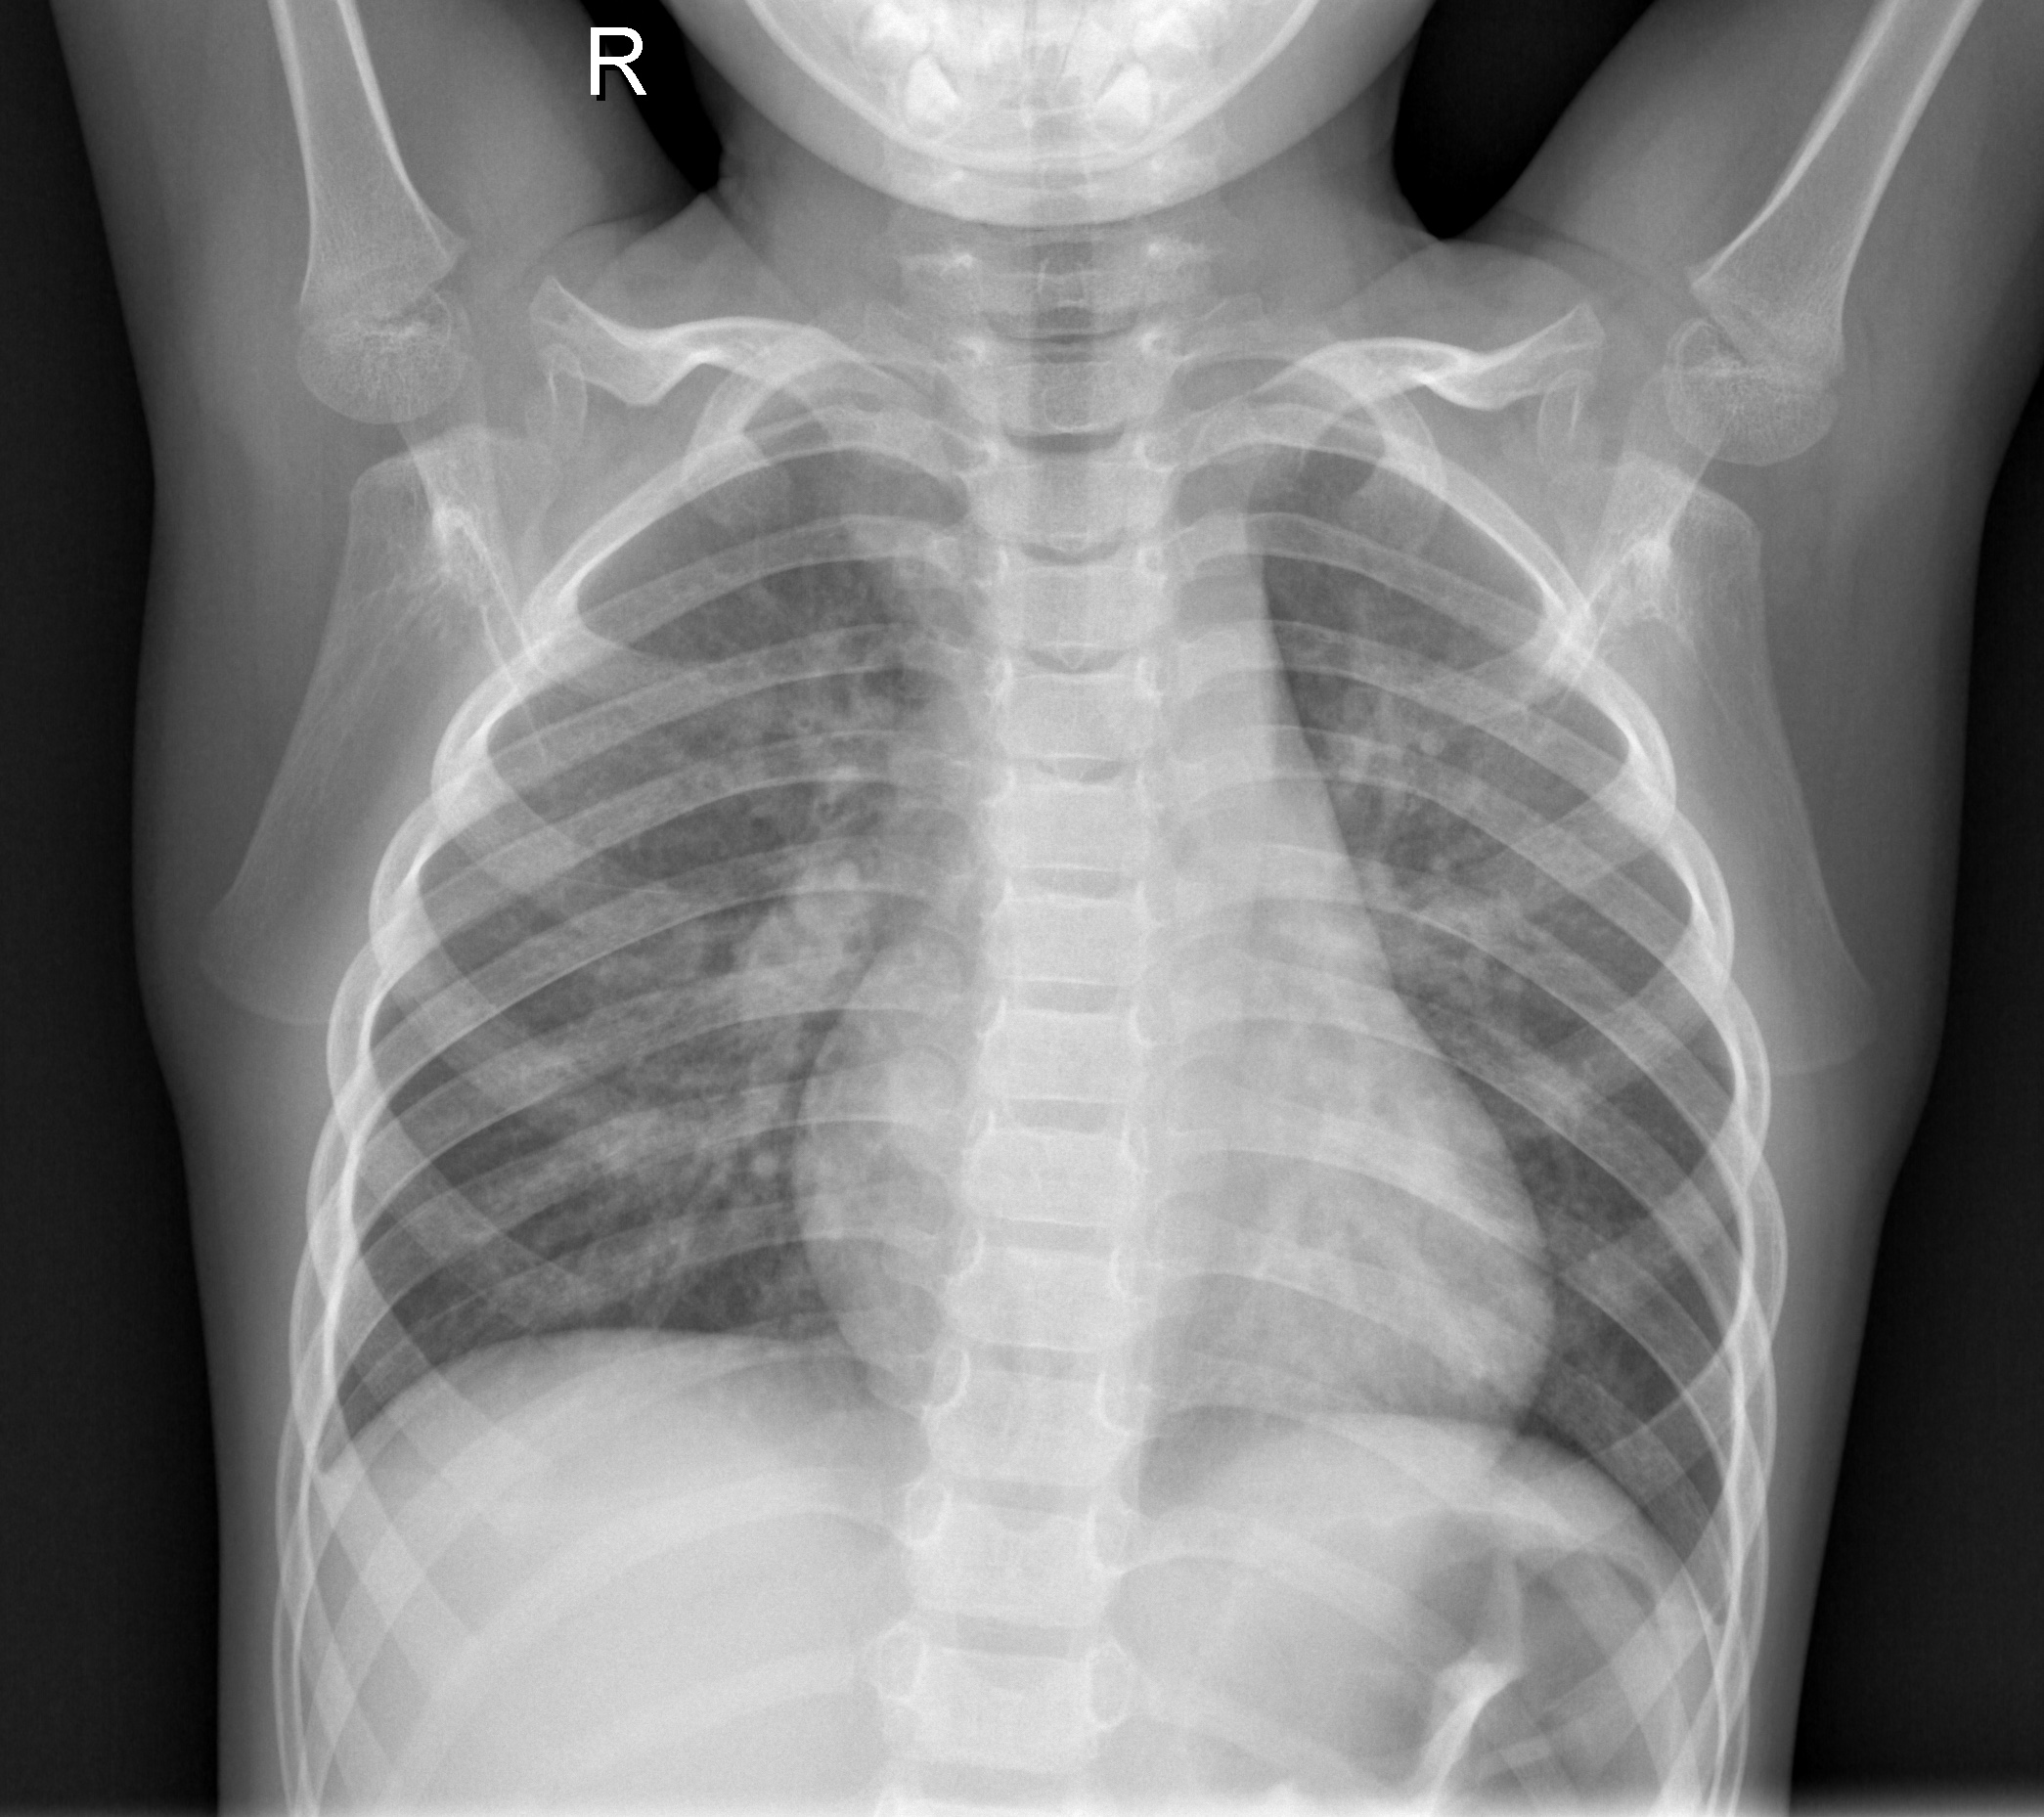

In [6]:
display(dataset["train"][0]["image"])

In [7]:
# loading the model from the huggingface
pneumonia_classifier = pipeline(model = 'lxyuan/vit-xray-pneumonia-classification')

# Generate the predictions (Whether the given image is Pneunomia or Not)
results = pneumonia_classifier.predict(dataset["train"][0]["image"])

# Find the label with the highest score and its score
highest = max(results, key = lambda x : x['score'])
highest_score_label = highest['label']
highest_score = highest['score'] * 100 # Convert to percentage

# Choose the correct verb based on the label
verb = 'is' if highest_score_label == 'NORMAL' else 'has'

# Print the result dynamically
print(f"Patient {verb} {highest_score_label} with Probability of ca. {highest_score: .0f}%")

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 10146.12it/s]


Patient is NORMAL with Probability of ca.  99%


In [16]:
patient_df['Gender'].unique().tolist()

['Female', 'Male']

### 1.4 Generate Synthetic Dataset - Using LLM

In [19]:
generate_synthetic_data = GeneratePatientData(
    ratio = ratio,
    n = patient_df.shape[0], 
    genders = patient_df['Gender'].unique().tolist()
)

response = generate_synthetic_data.crafting_prompt()

In [26]:
all_patients = pd.DataFrame(response)
print(f"Shape of the all patients dataframe : {all_patients.shape[0]}")
all_patients["Full_Name"] = all_patients["First_Name"] + "_" + all_patients["Last_Name"]
print(f"Shape of the unique patient id that are present in the dataset {len(all_patients['Full_Name'].unique())}")

Shape of the all patients dataframe : 349
Shape of the unique patient id that are present in the dataset 349


In [39]:
# Rename the column name 
all_patients.rename(
    columns = {'G_Gender': 'Gender'}, 
    inplace = True
)

# let's see the count on the both side
gender_counts = all_patients["Gender"].value_counts()
gender_counts 

# --- Our AI tool was able to generate equal gender ratio between the two

# Now, we are concatenating the all_patients dataframe and the patient_df dataframe
# So, now we are able to concatenate both the dataframes
updated_patient_df = pd.concat([patient_df, all_patients], axis = 1)
updated_patient_df.head(10)

# Now, let's remove the duplicated columns from the dataset
updated_patient_df = updated_patient_df.loc[:, ~updated_patient_df.columns.duplicated()]
print(f"Shape of the dataset: {updated_patient_df.shape}")
print(f"Distinct No. of Columns in the dataset: {updated_patient_df.columns}")


Shape of the dataset: (349, 14)
Distinct No. of Columns in the dataset: Index(['Disease', 'Fever', 'Cough', 'Fatigue', 'Difficulty Breathing', 'Age',
       'Gender', 'Blood Pressure', 'Cholesterol Level', 'Outcome Variable',
       'First_Name', 'Last_Name', 'Patient_ID', 'Full_Name'],
      dtype='str')


In [42]:
updated_patient_df.iloc[0 , :]

Disease                     Influenza
Fever                             Yes
Cough                              No
Fatigue                           Yes
Difficulty Breathing              Yes
Age                                19
Gender                         Female
Blood Pressure                    Low
Cholesterol Level              Normal
Outcome Variable             Positive
First_Name                      Aanya
Last_Name                      Sharma
Patient_ID              PAT1000000001
Full_Name                Aanya_Sharma
Name: 0, dtype: object

In [ ]:
updated_patient_df.to_csv('datasets/input/processed/updated_patient_df.csv')